Spectra data shape: (443, 900)
Labels data shape: (443, 1)


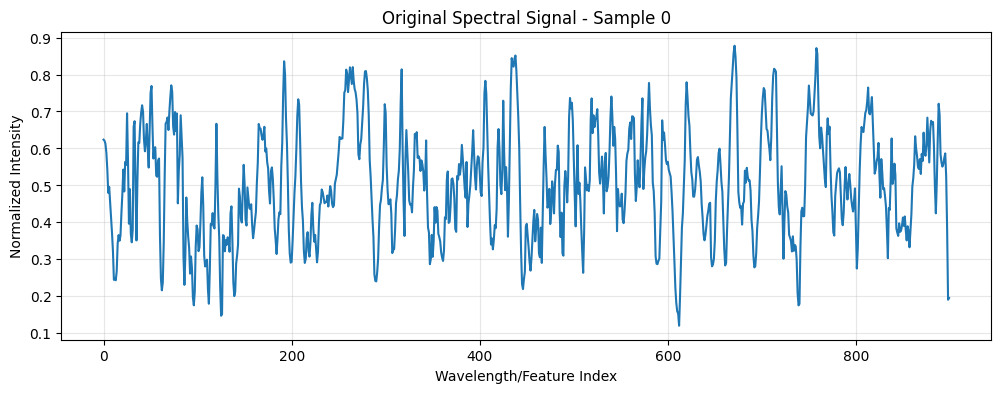

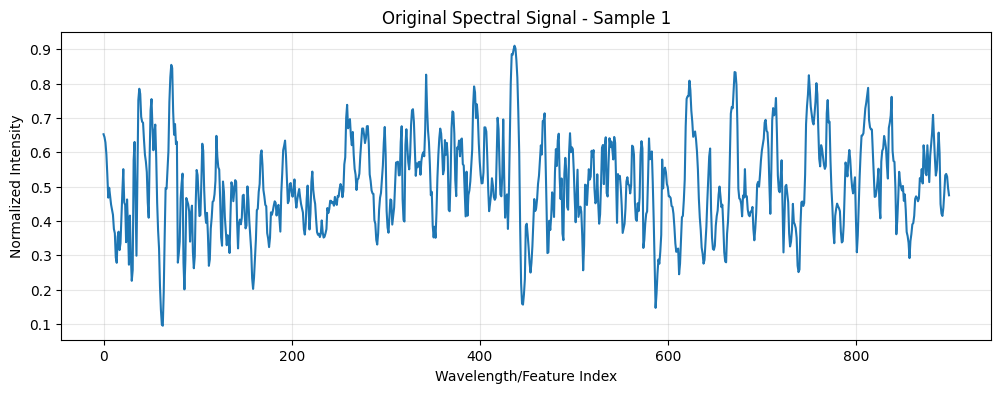

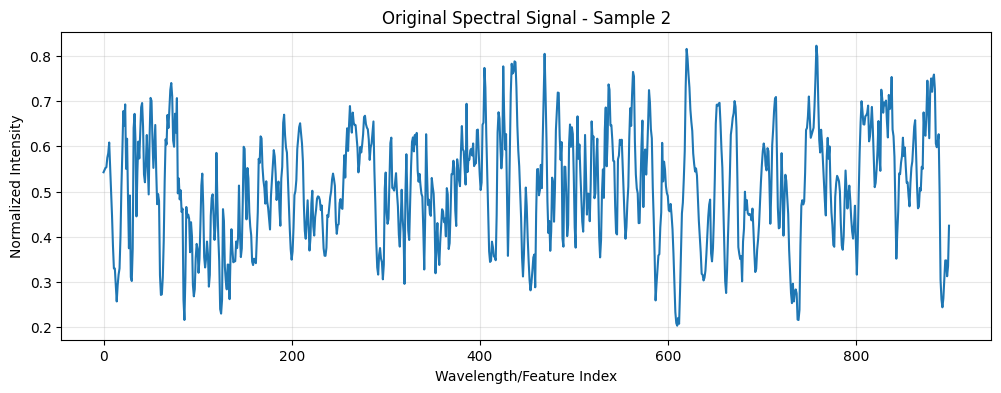

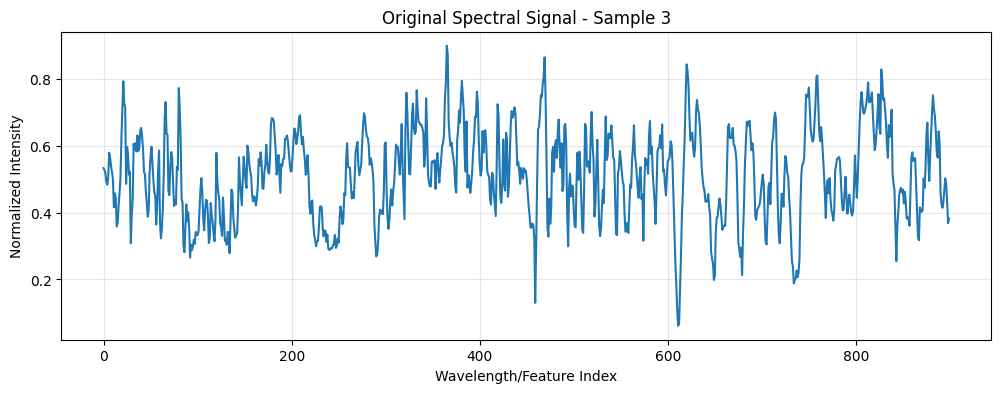

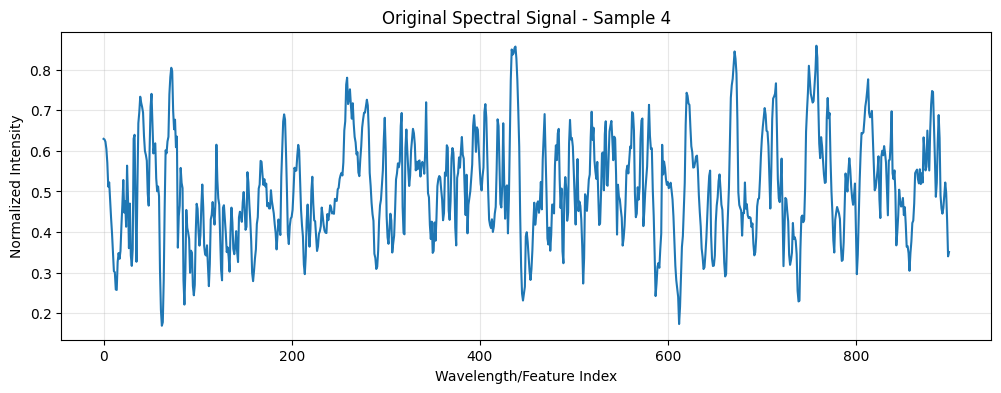

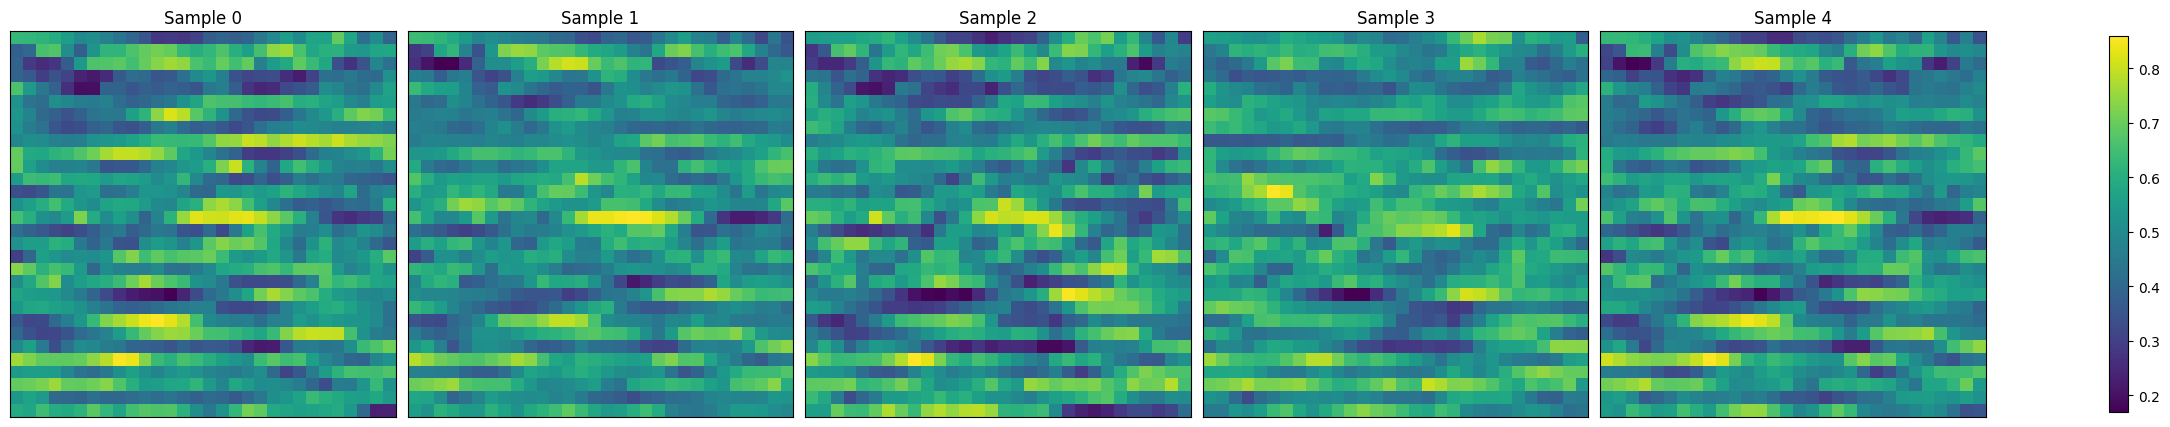

Reshaped image shape: (30, 30)


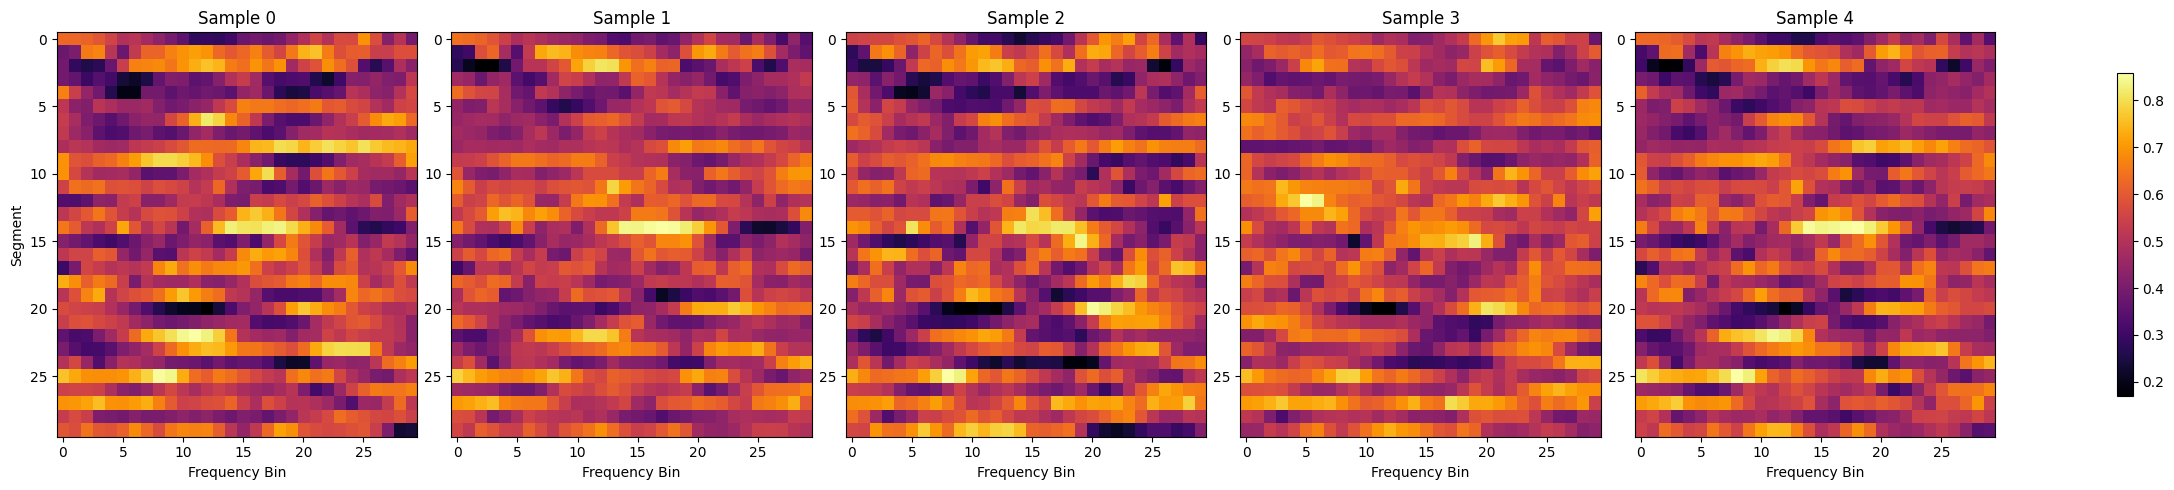

Spectrogram image shape: (30, 30)


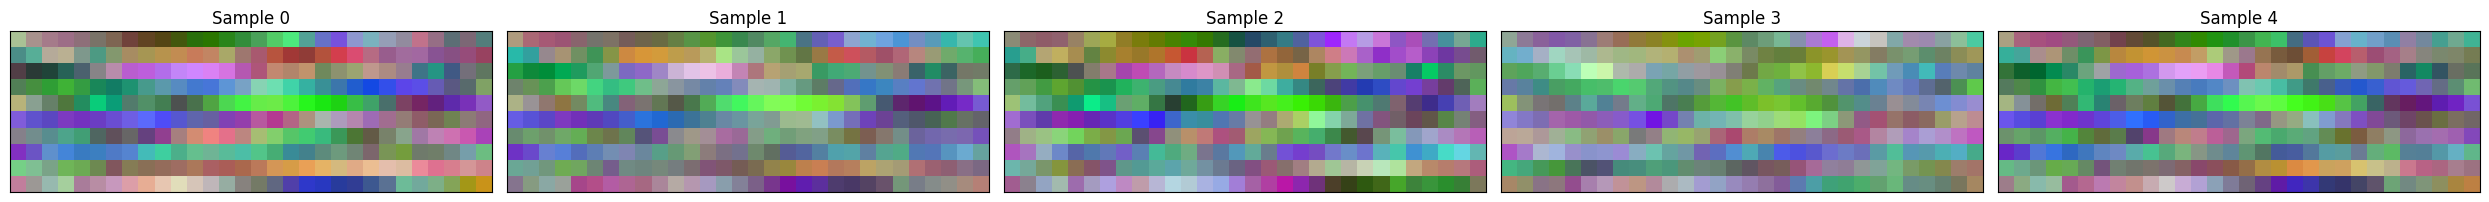

RGB image shape: (10, 30, 3)


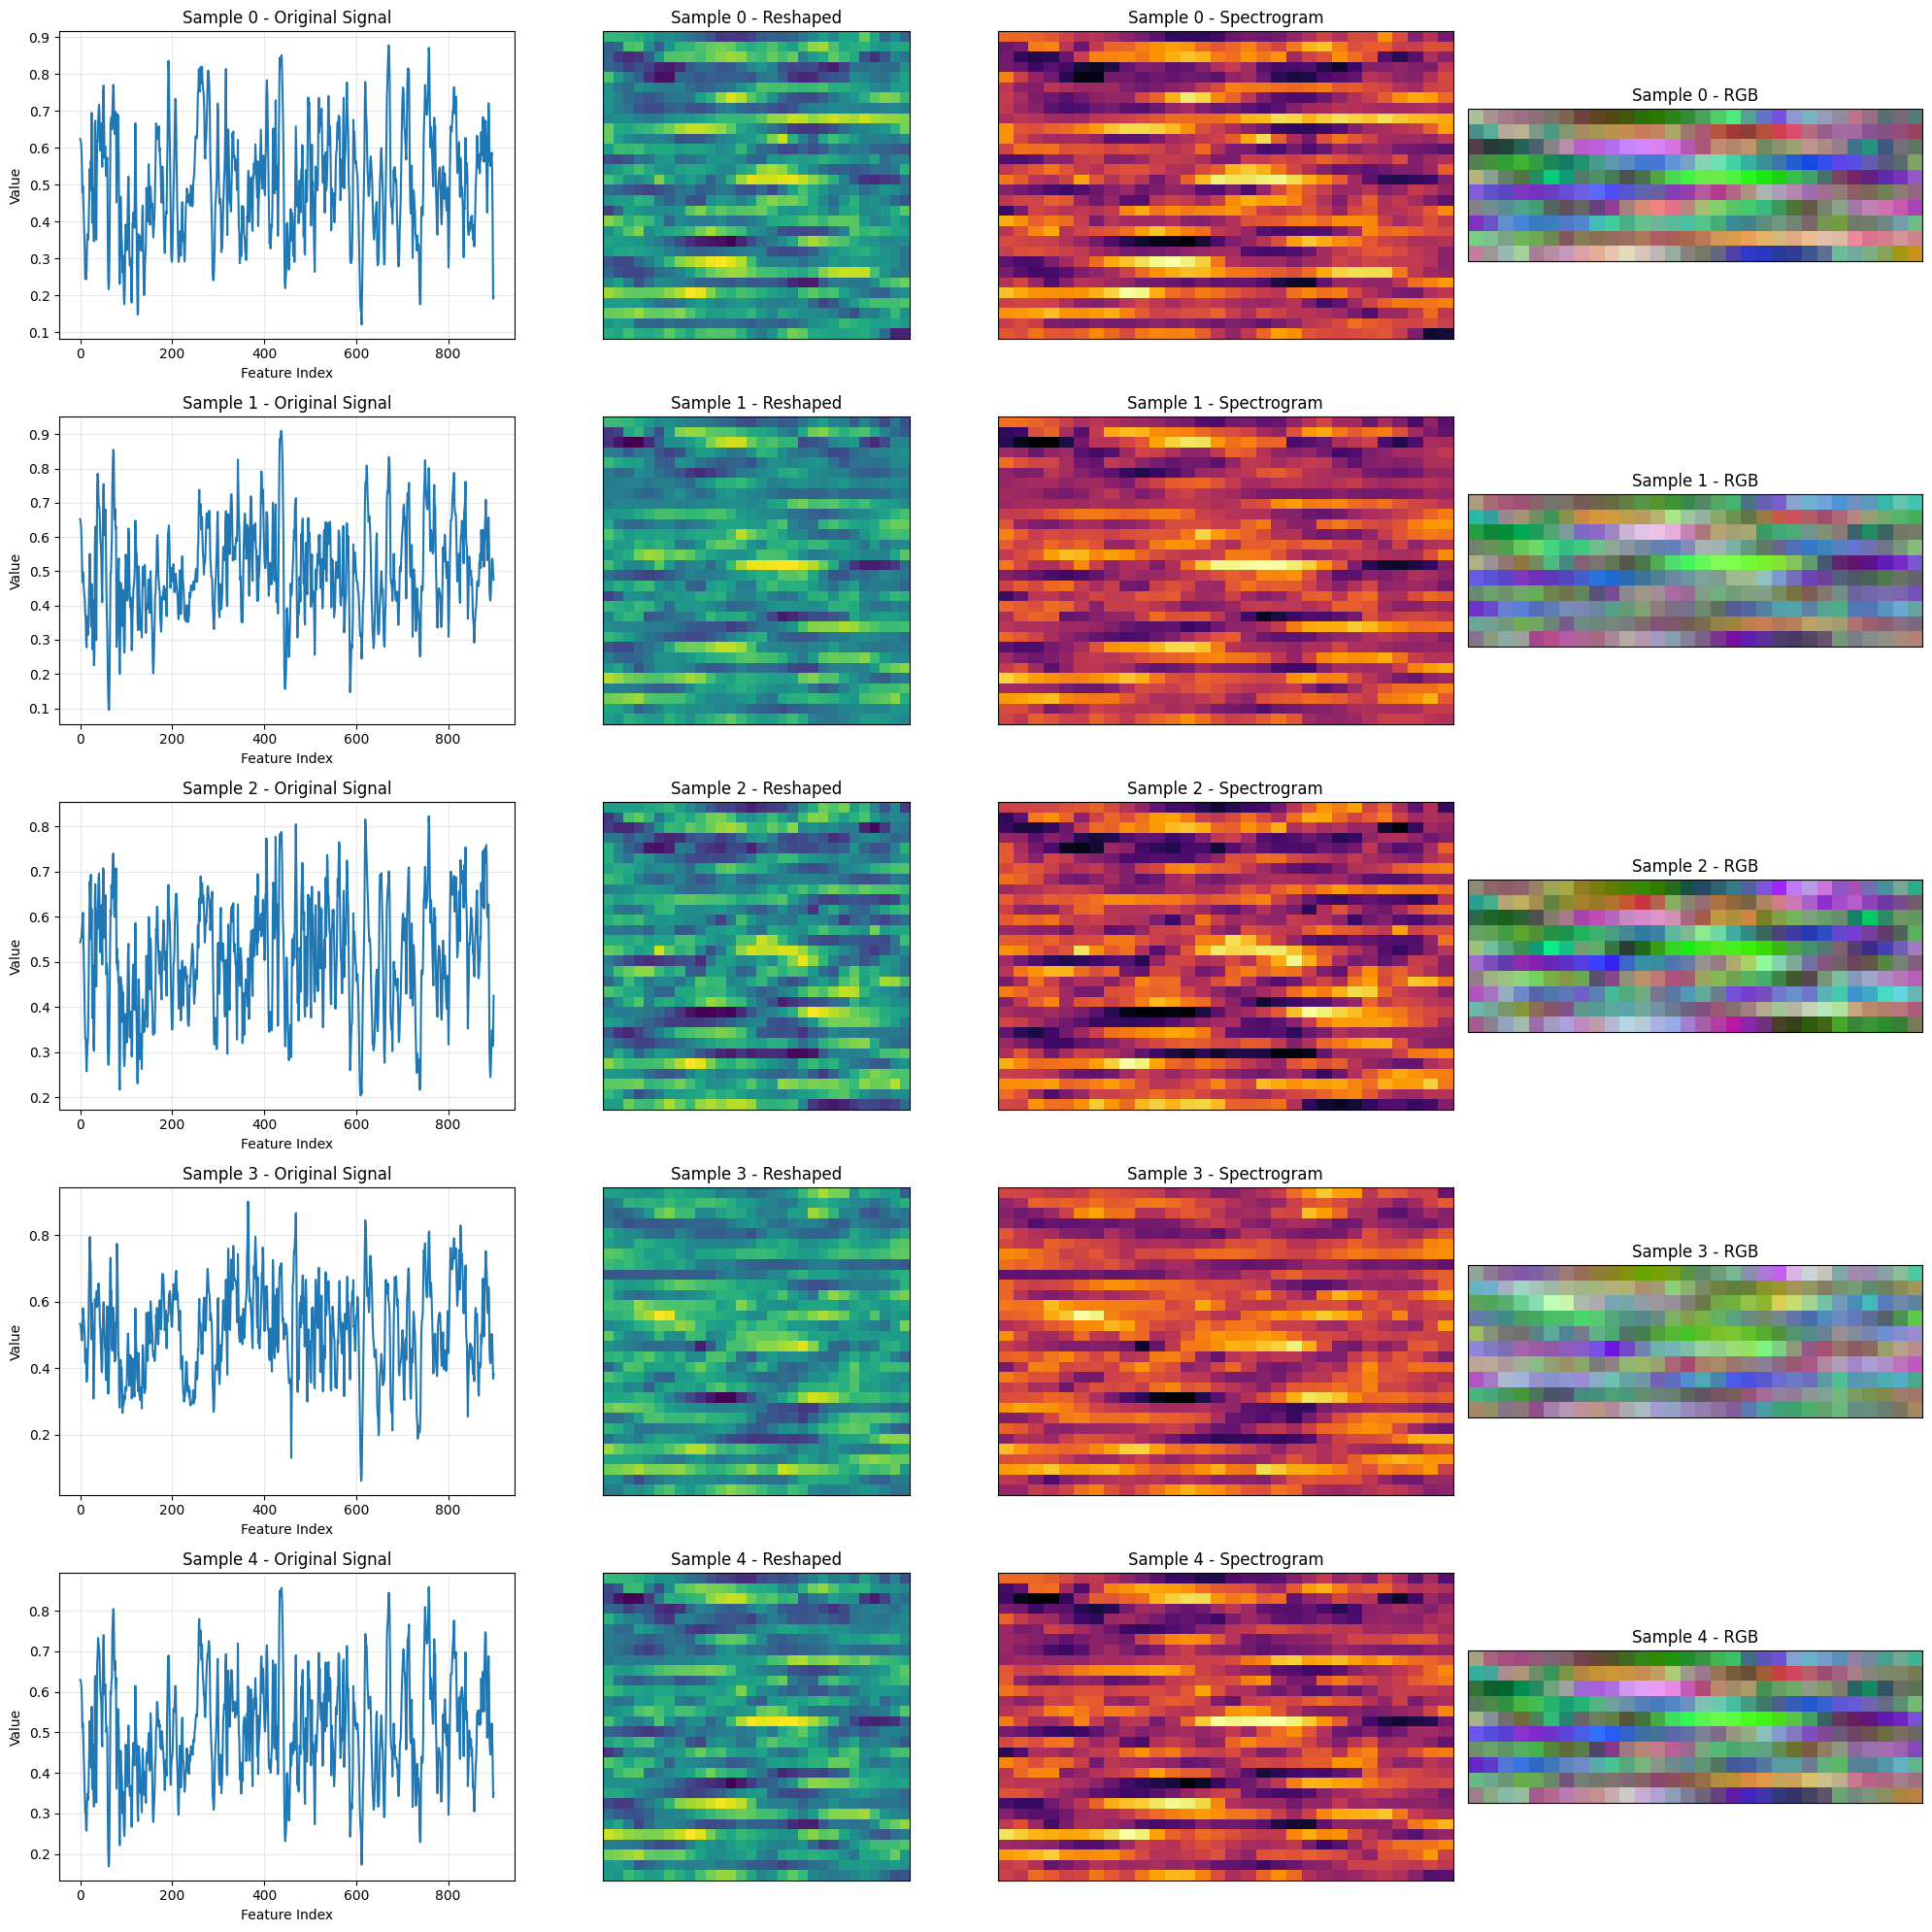

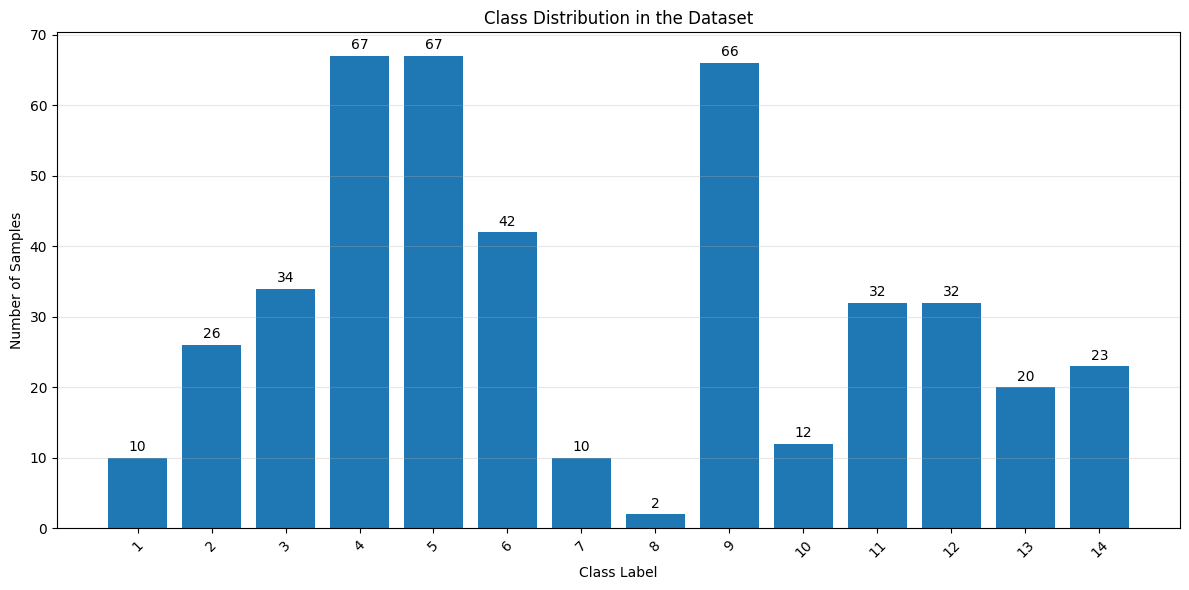

Class distribution:
Class 1: 10 samples (2.26%)
Class 2: 26 samples (5.87%)
Class 3: 34 samples (7.67%)
Class 4: 67 samples (15.12%)
Class 5: 67 samples (15.12%)
Class 6: 42 samples (9.48%)
Class 7: 10 samples (2.26%)
Class 8: 2 samples (0.45%)
Class 9: 66 samples (14.90%)
Class 10: 12 samples (2.71%)
Class 11: 32 samples (7.22%)
Class 12: 32 samples (7.22%)
Class 13: 20 samples (4.51%)
Class 14: 23 samples (5.19%)

----- Summary of Spectral Data to Image Conversion -----

Dataset dimensions: 443 samples with 900 features each

Transformation Methods:
1. Reshape Method:
   - Output shape: (30, 30)
   - Preserves all values but may lose spectral continuity
   - Best for signals where spatial relationship is not critical

2. Spectrogram Method:
   - Output shape: (30, 30)
   - Preserves temporal/frequency segments
   - Good for capturing patterns across frequency bands

3. RGB Method:
   - Output shape: (10, 30, 3)
   - Provides color channels that CNNs are typically trained for
   - May

In [ ]:
# Visualization and Evaluation of Spectral Data Conversions
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Create output directory for images if it doesn't exist
output_dir = 'spectral_visualizations'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Load the spectral data
spectra_data = pd.read_excel('minmax_normalized_dataset.xlsx')

# Load the labels
labels_data = pd.read_csv('idC_with_header.csv')

print(f"Spectra data shape: {spectra_data.shape}")
print(f"Labels data shape: {labels_data.shape}")

# Function to visualize original signal
def visualize_original_signal(spectrum, idx, save=True):
    plt.figure(figsize=(12, 4))
    plt.plot(spectrum)
    plt.title(f'Original Spectral Signal - Sample {idx}')
    plt.xlabel('Wavelength/Feature Index')
    plt.ylabel('Normalized Intensity')
    plt.grid(True, alpha=0.3)
    
    if save:
        plt.savefig(f'{output_dir}/original_signal_{idx}.png', dpi=300, bbox_inches='tight')
    
    plt.show()

# Visualize a few original signals
for i in range(min(5, len(spectra_data))):
    visualize_original_signal(spectra_data.iloc[i].values, i)

# 1. Reshape Method Visualization
def spectra_to_image_reshape(spectra, width=30, height=30):
    target_size = width * height
    
    if len(spectra) > target_size:
        resized_spectra = spectra[:target_size]
    else:
        resized_spectra = np.pad(spectra, (0, target_size - len(spectra)), 'constant')
    
    img = resized_spectra.reshape(width, height)
    return img

# Visualize reshaped images for multiple samples
def visualize_reshaped_images(spectra_data, num_samples=5, width=30, height=30, save=True):
    # Take a subset of samples
    samples = min(num_samples, len(spectra_data))
    
    # Create a grid of plots
    fig, axes = plt.subplots(1, samples, figsize=(samples*5, 5))
    
    for i in range(samples):
        spectrum = spectra_data.iloc[i].values
        img = spectra_to_image_reshape(spectrum, width, height)
        
        if samples == 1:
            ax = axes
        else:
            ax = axes[i]
        
        im = ax.imshow(img, cmap='viridis')
        ax.set_title(f'Sample {i}')
        ax.set_xticks([])
        ax.set_yticks([])
    
    plt.tight_layout()
    fig.colorbar(im, ax=axes, shrink=0.8)
    
    if save:
        plt.savefig(f'{output_dir}/reshaped_images_{samples}_samples.png', dpi=300, bbox_inches='tight')
    
    plt.show()
    
    # Return the first image for demonstration
    return spectra_to_image_reshape(spectra_data.iloc[0].values, width, height)

reshape_img = visualize_reshaped_images(spectra_data, num_samples=5)
print(f"Reshaped image shape: {reshape_img.shape}")

# 2. Spectrogram Method Visualization
def spectra_to_spectrogram(spectra, n_segments=30):
    segment_size = len(spectra) // n_segments
    
    spectrogram = np.zeros((n_segments, segment_size))
    
    for i in range(n_segments):
        start = i * segment_size
        end = start + segment_size
        if end <= len(spectra):
            spectrogram[i, :] = spectra[start:end]
    
    return spectrogram

# Visualize spectrograms for multiple samples
def visualize_spectrograms(spectra_data, num_samples=5, n_segments=30, save=True):
    samples = min(num_samples, len(spectra_data))
    
    fig, axes = plt.subplots(1, samples, figsize=(samples*5, 5))
    
    for i in range(samples):
        spectrum = spectra_data.iloc[i].values
        spectrogram = spectra_to_spectrogram(spectrum, n_segments)
        
        if samples == 1:
            ax = axes
        else:
            ax = axes[i]
        
        im = ax.imshow(spectrogram, aspect='auto', cmap='inferno')
        ax.set_title(f'Sample {i}')
        
        if i == 0:
            ax.set_ylabel('Segment')
        
        ax.set_xlabel('Frequency Bin')
    
    plt.tight_layout()
    fig.colorbar(im, ax=axes, shrink=0.8)
    
    if save:
        plt.savefig(f'{output_dir}/spectrograms_{samples}_samples.png', dpi=300, bbox_inches='tight')
    
    plt.show()
    
    # Return the first spectrogram for demonstration
    return spectra_to_spectrogram(spectra_data.iloc[0].values, n_segments)

spectrogram_img = visualize_spectrograms(spectra_data, num_samples=5)
print(f"Spectrogram image shape: {spectrogram_img.shape}")

# 3. RGB Method Visualization
def spectra_to_rgb(spectra, width=30, height=10):
    if len(spectra) < width * height * 3:
        spectra = np.pad(spectra, (0, width * height * 3 - len(spectra)), 'constant')
    
    third = width * height
    r_channel = spectra[:third].reshape(height, width)
    g_channel = spectra[third:2*third].reshape(height, width)
    b_channel = spectra[2*third:3*third].reshape(height, width)
    
    rgb_img = np.stack([r_channel, g_channel, b_channel], axis=2)
    
    rgb_img = (rgb_img - rgb_img.min()) / (rgb_img.max() - rgb_img.min())
    
    return rgb_img

# Visualize RGB images for multiple samples
def visualize_rgb_images(spectra_data, num_samples=5, width=30, height=10, save=True):
    samples = min(num_samples, len(spectra_data))
    
    fig, axes = plt.subplots(1, samples, figsize=(samples*5, 4))
    
    for i in range(samples):
        spectrum = spectra_data.iloc[i].values
        rgb_img = spectra_to_rgb(spectrum, width, height)
        
        if samples == 1:
            ax = axes
        else:
            ax = axes[i]
        
        ax.imshow(rgb_img)
        ax.set_title(f'Sample {i}')
        ax.set_xticks([])
        ax.set_yticks([])
    
    plt.tight_layout()
    
    if save:
        plt.savefig(f'{output_dir}/rgb_images_{samples}_samples.png', dpi=300, bbox_inches='tight')
    
    plt.show()
    
    # Return the first RGB image for demonstration
    return spectra_to_rgb(spectra_data.iloc[0].values, width, height)

rgb_img = visualize_rgb_images(spectra_data, num_samples=5)
print(f"RGB image shape: {rgb_img.shape}")

# Process all data and save as PNG files
def process_all_data(spectra_data, labels_data, n_samples=None, save_dir='processed_images'):
    """
    Process all spectral data using all three methods and save as PNG files
    organized by class/label
    """
    if n_samples is None:
        n_samples = len(spectra_data)
    else:
        n_samples = min(n_samples, len(spectra_data))
    
    # Create main directory
    if not os.path.exists(save_dir):
        os.makedirs(save_dir)
    
    # Create subdirectories for each method
    reshape_dir = os.path.join(save_dir, 'reshaped')
    spectro_dir = os.path.join(save_dir, 'spectrogram')
    rgb_dir = os.path.join(save_dir, 'rgb')
    
    for d in [reshape_dir, spectro_dir, rgb_dir]:
        if not os.path.exists(d):
            os.makedirs(d)
    
    # Get unique labels
    label_encoder = LabelEncoder()
    y = label_encoder.fit_transform(labels_data.iloc[:, 0])
    classes = label_encoder.classes_
    
    # Create class directories
    for method_dir in [reshape_dir, spectro_dir, rgb_dir]:
        for cls in classes:
            cls_dir = os.path.join(method_dir, str(cls))
            if not os.path.exists(cls_dir):
                os.makedirs(cls_dir)
    
    # Process and save images
    print(f"Processing {n_samples} samples and saving to {save_dir}...")
    
    for i in range(n_samples):
        if i % 50 == 0:
            print(f"Processing sample {i}/{n_samples}")
        
        spectrum = spectra_data.iloc[i].values
        label = labels_data.iloc[i, 0]
        
        # 1. Reshaped method
        img_reshape = spectra_to_image_reshape(spectrum)
        plt.figure(figsize=(3, 3))
        plt.imshow(img_reshape, cmap='viridis')
        plt.axis('off')
        plt.savefig(os.path.join(reshape_dir, str(label), f'sample_{i}.png'), 
                   dpi=100, bbox_inches='tight', pad_inches=0)
        plt.close()
        
        # 2. Spectrogram method
        img_spectro = spectra_to_spectrogram(spectrum)
        plt.figure(figsize=(3, 3))
        plt.imshow(img_spectro, aspect='auto', cmap='inferno')
        plt.axis('off')
        plt.savefig(os.path.join(spectro_dir, str(label), f'sample_{i}.png'), 
                   dpi=100, bbox_inches='tight', pad_inches=0)
        plt.close()
        
        # 3. RGB method
        img_rgb = spectra_to_rgb(spectrum)
        plt.figure(figsize=(3, 3))
        plt.imshow(img_rgb)
        plt.axis('off')
        plt.savefig(os.path.join(rgb_dir, str(label), f'sample_{i}.png'), 
                   dpi=100, bbox_inches='tight', pad_inches=0)
        plt.close()
    
    print(f"Finished processing {n_samples} samples.")
    return reshape_dir, spectro_dir, rgb_dir

# Process a subset of the data and save as PNG
# Comment out if you don't want to save all images
# reshape_dir, spectro_dir, rgb_dir = process_all_data(spectra_data, labels_data, n_samples=100)

# ------------------- Evaluation of the Methods -------------------

# Function to compare the three methods
def compare_methods(spectra_data, num_samples=5):
    samples = min(num_samples, len(spectra_data))
    
    fig, axes = plt.subplots(samples, 4, figsize=(20, samples*4))
    
    for i in range(samples):
        spectrum = spectra_data.iloc[i].values
        
        # Original signal
        axes[i, 0].plot(spectrum)
        axes[i, 0].set_title(f'Sample {i} - Original Signal')
        axes[i, 0].set_xlabel('Feature Index')
        axes[i, 0].set_ylabel('Value')
        axes[i, 0].grid(True, alpha=0.3)
        
        # Reshaped
        img_reshape = spectra_to_image_reshape(spectrum)
        axes[i, 1].imshow(img_reshape, cmap='viridis')
        axes[i, 1].set_title(f'Sample {i} - Reshaped')
        axes[i, 1].set_xticks([])
        axes[i, 1].set_yticks([])
        
        # Spectrogram
        img_spectro = spectra_to_spectrogram(spectrum)
        axes[i, 2].imshow(img_spectro, aspect='auto', cmap='inferno')
        axes[i, 2].set_title(f'Sample {i} - Spectrogram')
        axes[i, 2].set_xticks([])
        axes[i, 2].set_yticks([])
        
        # RGB
        img_rgb = spectra_to_rgb(spectrum)
        axes[i, 3].imshow(img_rgb)
        axes[i, 3].set_title(f'Sample {i} - RGB')
        axes[i, 3].set_xticks([])
        axes[i, 3].set_yticks([])
    
    plt.tight_layout()
    plt.savefig(f'{output_dir}/method_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

# Compare the three methods visually
compare_methods(spectra_data, num_samples=5)

# Analyze class distribution
def analyze_class_distribution(labels_data):
    # Get the labels
    labels = labels_data.iloc[:, 0]
    
    # Count frequency of each class
    class_counts = labels.value_counts().sort_index()
    
    # Plot the distribution
    plt.figure(figsize=(12, 6))
    bars = plt.bar(class_counts.index.astype(str), class_counts.values)
    
    # Add count labels above bars
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                f'{int(height)}', ha='center', va='bottom')
    
    plt.title('Class Distribution in the Dataset')
    plt.xlabel('Class Label')
    plt.ylabel('Number of Samples')
    plt.xticks(rotation=45)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{output_dir}/class_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("Class distribution:")
    for label, count in class_counts.items():
        print(f"Class {label}: {count} samples ({count/len(labels)*100:.2f}%)")

# Analyze class distribution
analyze_class_distribution(labels_data)

print("\n----- Summary of Spectral Data to Image Conversion -----\n")
print(f"Dataset dimensions: {spectra_data.shape[0]} samples with {spectra_data.shape[1]} features each")

print("\nTransformation Methods:")
print("1. Reshape Method:")
print(f"   - Output shape: {reshape_img.shape}")
print("   - Preserves all values but may lose spectral continuity")
print("   - Best for signals where spatial relationship is not critical")

print("\n2. Spectrogram Method:")
print(f"   - Output shape: {spectrogram_img.shape}")
print("   - Preserves temporal/frequency segments")
print("   - Good for capturing patterns across frequency bands")

print("\n3. RGB Method:")
print(f"   - Output shape: {rgb_img.shape}")
print("   - Provides color channels that CNNs are typically trained for")
print("   - May benefit from transfer learning with pre-trained models")

